In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import json 
import numpy as np
import networkx as nx
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
import sys
sys.path.append("../src/")
sys.path.append("/data/bionets/je30bery/truncated_graphs/src/")
from truncated_graphs import *
from sern import *
from data import *

In [3]:
adata = get_mibitof_with_spatial(crop=True)

In [4]:
surrogates = build_serns_from_anndata(adata, n_surr=500, n_bins=40, seed=42, return_p_of_d=False)

Generating SERNs: 100%|█████████████████████████████████████████| 500/500 [00:00<00:00, 1461.14it/s]


In [5]:
deg_orig, deg_mean, deg_std, deg_z = degree_zscore_from_serns(adata, surrogates)

In [6]:
G = nx_from_adata(adata)
pos = nx.get_node_attributes(G, "pos")

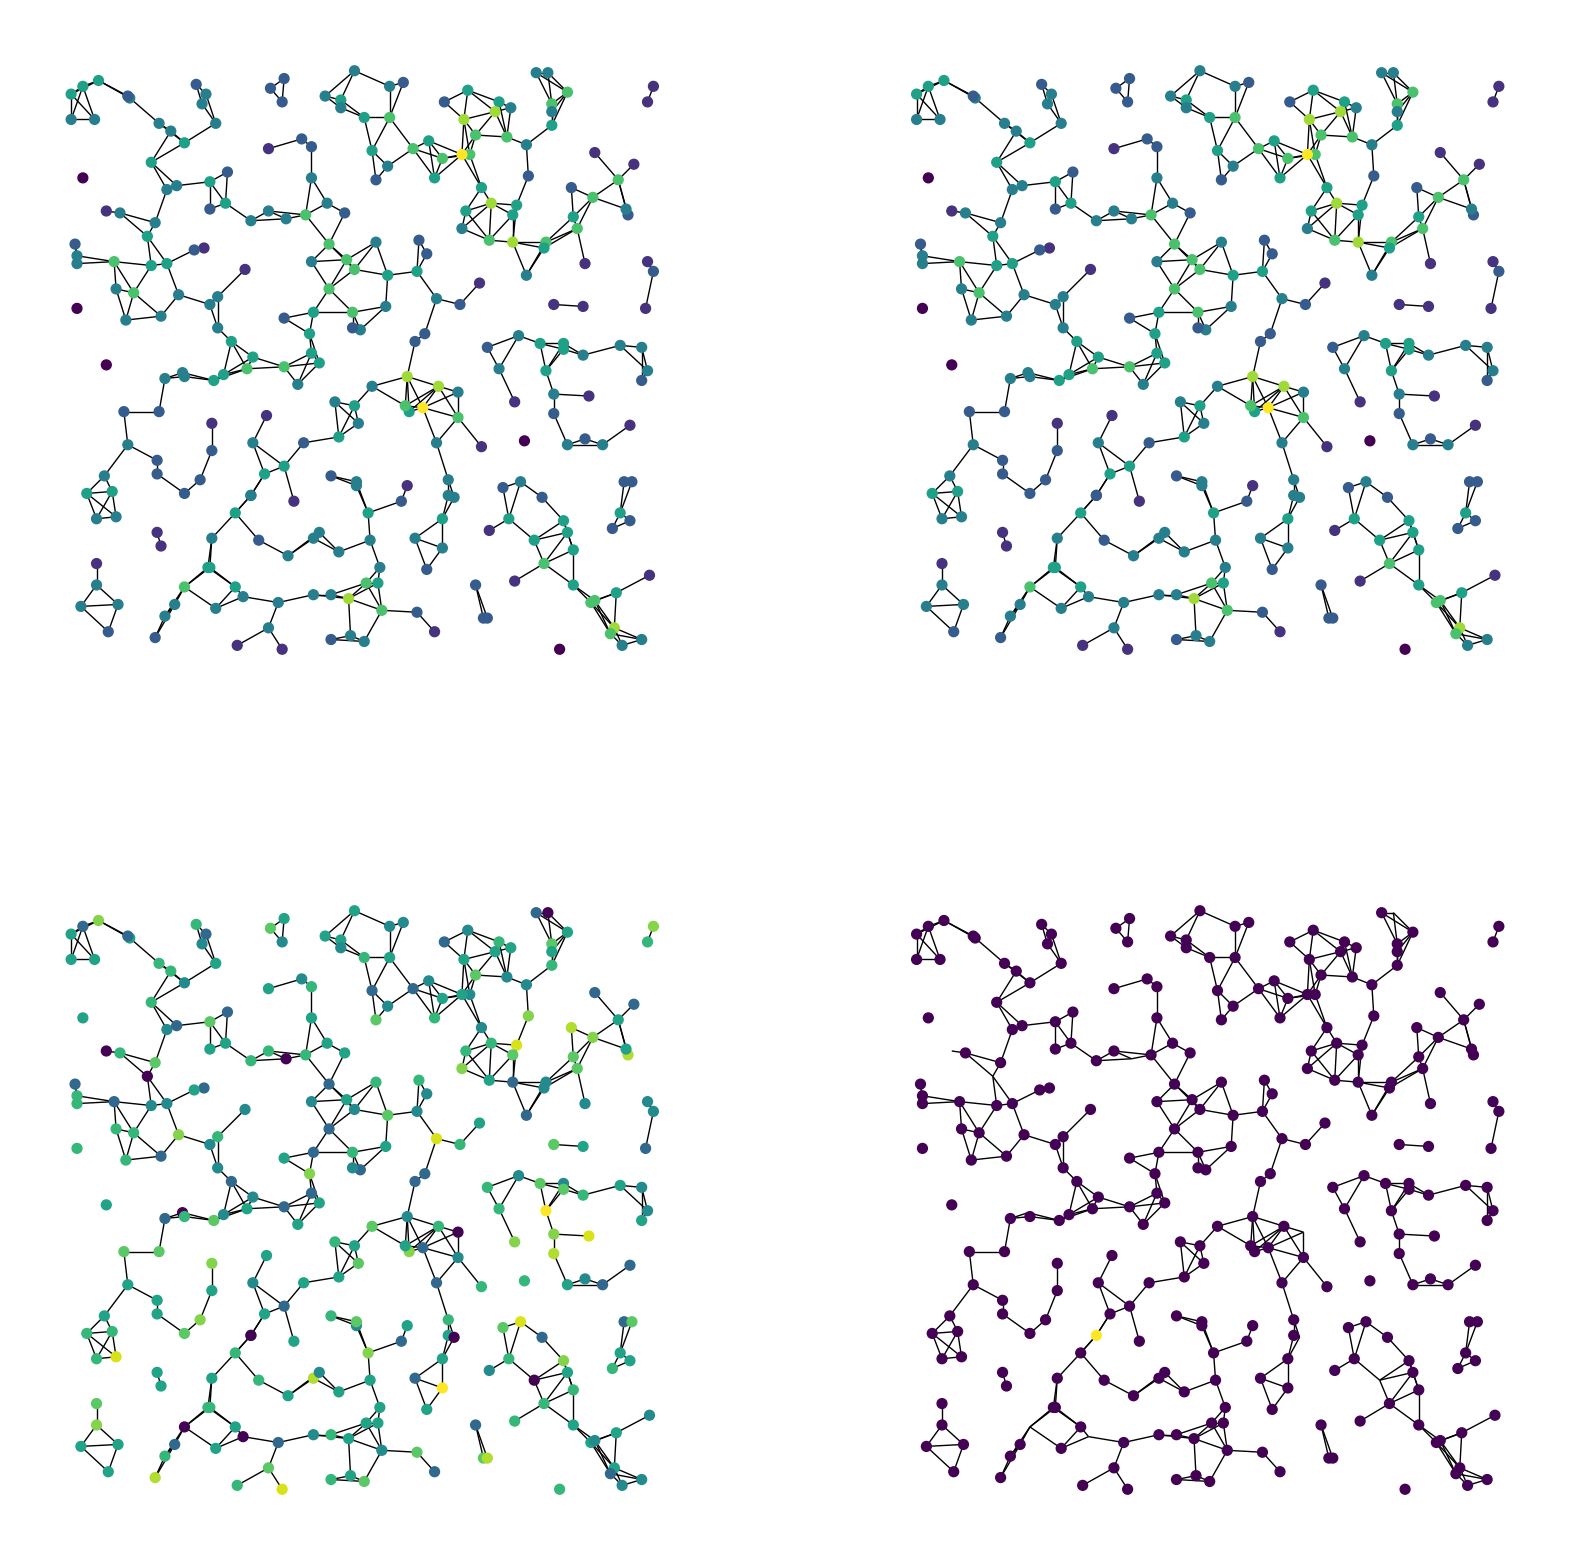

In [7]:
f, axs = plt.subplots(2, 2, figsize=(20, 20))
nx.draw(G, pos=pos, node_color=deg_orig, ax=axs[0, 0], node_size=50)
nx.draw(G, pos=pos, node_color=deg_mean, ax=axs[0, 1], node_size=50)
nx.draw(G, pos=pos, node_color=deg_std, ax=axs[1, 0], node_size=50)
nx.draw(G, pos=pos, node_color=deg_z, ax=axs[1, 1], node_size=50)